In [30]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import kagglehub

path = kagglehub.dataset_download(
    "khaledhellmy/brain-breast-tumor",
    output_dir="../data"
)

print("Dataset downloaded to:", path)

100%|██████████| 222M/222M [04:49<00:00, 803kB/s]  

Extracting files...


Dataset downloaded to: ../data


In [8]:
import numpy as np
import pandas as pd


import os
for dirname,_,filenames in os.walk('../Data'):
    for filename in filenames:
        print(os.path.join(dirname,filename))

../Data\Brain scans\No tumor\Test\no501.jpg
../Data\Brain scans\No tumor\Test\no502.jpg
../Data\Brain scans\No tumor\Test\no503.jpg
../Data\Brain scans\No tumor\Test\no504.jpg
../Data\Brain scans\No tumor\Test\no505.jpg
../Data\Brain scans\No tumor\Test\no506.jpg
../Data\Brain scans\No tumor\Test\no507.jpg
../Data\Brain scans\No tumor\Test\no508.jpg
../Data\Brain scans\No tumor\Test\no509.jpg
../Data\Brain scans\No tumor\Test\no510.jpg
../Data\Brain scans\No tumor\Test\no511.jpg
../Data\Brain scans\No tumor\Test\no512.jpg
../Data\Brain scans\No tumor\Test\no513.jpg
../Data\Brain scans\No tumor\Test\no514.jpg
../Data\Brain scans\No tumor\Test\no515.jpg
../Data\Brain scans\No tumor\Test\no516.jpg
../Data\Brain scans\No tumor\Test\no517.jpg
../Data\Brain scans\No tumor\Test\no518.jpg
../Data\Brain scans\No tumor\Test\no519.jpg
../Data\Brain scans\No tumor\Test\no520.jpg
../Data\Brain scans\No tumor\Test\no521.jpg
../Data\Brain scans\No tumor\Test\no522.jpg
../Data\Brain scans\No tumor\Tes

In [9]:
print("Data Download")

Data Download


In [12]:
import pandas as pd
import os

base_paths = [
    ("../Data/Brain scans/No tumor/Train", "No tumor", "Train"),
    ("../Data/Brain scans/No tumor/Test", "No tumor", "Test"),

    ("../Data/Brain scans/Tumor/TRAIN", "Tumor", "Train"),
    ("../Data/Brain scans/Tumor/TEST", "Tumor", "Test"),

    ("../Data/Breast scans/benign/Train", "benign", "Train"),
    ("../Data/Breast scans/benign/Test", "benign", "Test"),

    ("../Data/Breast scans/malignant/Train", "malignant", "Train"),
    ("../Data/Breast scans/malignant/Test", "malignant", "Test"),

    ("../Data/Breast scans/normal/Train", "normal", "Train"),
    ("../Data/Breast scans/normal/Test", "normal", "Test")
]

import os
import pandas as pd

def collention_image_data():
    image_paths = []
    labels = []
    splits = []

    for path, label, split in base_paths:

        # Check whether directory exists
        if not os.path.exists(path):
            print(f"Warning: Directory {path} does not exist.")
            continue

        # Collect images
        for filename in os.listdir(path):

            img_path = os.path.join(path, filename)

            # Only process image files
            if filename.lower().endswith((".jpg", ".jpeg", ".png")):

                image_paths.append(img_path)
                labels.append(label)
                splits.append(split)

    return image_paths, labels, splits


image_paths, labels, splits = collention_image_data()

df = pd.DataFrame({
    "Image_Path": image_paths,
    "Label": labels,
    "Split": splits
})

print("Total images:", len(df))
print(df.head())

Total images: 2645
                                     Image_Path     Label  Split
0    ../Data/Brain scans/No tumor/Train\no0.jpg  No tumor  Train
1    ../Data/Brain scans/No tumor/Train\no1.jpg  No tumor  Train
2   ../Data/Brain scans/No tumor/Train\no10.jpg  No tumor  Train
3  ../Data/Brain scans/No tumor/Train\no100.jpg  No tumor  Train
4  ../Data/Brain scans/No tumor/Train\no101.jpg  No tumor  Train


In [13]:
df

,Image_Path,Label,Split
0,../Data/Brain scans/No tumor/Train\no0.jpg,No tumor,Train
1,../Data/Brain scans/No tumor/Train\no1.jpg,No tumor,Train
2,../Data/Brain scans/No tumor/Train\no10.jpg,No tumor,Train
3,../Data/Brain scans/No tumor/Train\no100.jpg,No tumor,Train
4,../Data/Brain scans/No tumor/Train\no101.jpg,No tumor,Train
...,...,...,...
2640,../Data/Breast scans/normal/Test\normal (129).png,normal,Test
2641,../Data/Breast scans/normal/Test\normal (130).png,normal,Test
2642,../Data/Breast scans/normal/Test\normal (131).png,normal,Test
2643,../Data/Breast scans/normal/Test\normal (132).png,normal,Test


In [14]:
df=df[['Image_Path','Label']]

In [15]:
df

,Image_Path,Label
0,../Data/Brain scans/No tumor/Train\no0.jpg,No tumor
1,../Data/Brain scans/No tumor/Train\no1.jpg,No tumor
2,../Data/Brain scans/No tumor/Train\no10.jpg,No tumor
3,../Data/Brain scans/No tumor/Train\no100.jpg,No tumor
4,../Data/Brain scans/No tumor/Train\no101.jpg,No tumor
...,...,...
2640,../Data/Breast scans/normal/Test\normal (129).png,normal
2641,../Data/Breast scans/normal/Test\normal (130).png,normal
2642,../Data/Breast scans/normal/Test\normal (131).png,normal
2643,../Data/Breast scans/normal/Test\normal (132).png,normal


## EDA - EXPLORATORY DATA ANALYSIS

In [16]:
df.shape

(2645, 2)

In [17]:
df.columns

Index(['Image_Path', 'Label'], dtype='str')

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum()

Image_Path    0
Label         0
dtype: int64

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2645 entries, 0 to 2644
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Image_Path  2645 non-null   str  
 1   Label       2645 non-null   str  
dtypes: str(2)
memory usage: 183.2 KB


In [21]:
df['Label'].unique()

<ArrowStringArray>
['No tumor', 'Tumor', 'benign', 'malignant', 'normal']
Length: 5, dtype: str

'No tumor', 'Tumor', 'benign', 'malignant', 'normal'

MULTI CLASS CLASSIFICATION

CHECK COUNT 

In [22]:
df['Label'].value_counts()

Label
benign       891
No tumor     601
Tumor        600
malignant    420
normal       133
Name: count, dtype: int64

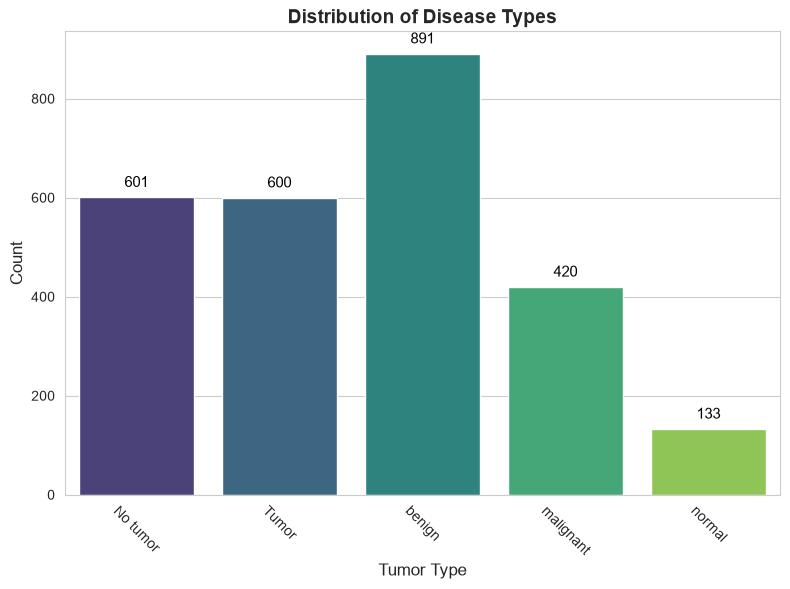

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

fig,ax=plt.subplots(figsize=(8,6))
sns.countplot(data=df,x='Label',palette='viridis',ax=ax)
ax.set_title("Distribution of Disease Types",fontsize=14,fontweight='bold')
ax.set_xlabel('Tumor Type',fontsize=12)
ax.set_ylabel('Count',fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2.,p.get_height()),
                ha='center',va='bottom',fontsize=11,color='black',
                xytext=(0,5),textcoords='offset points')
plt.xticks(rotation=-45)
plt.tight_layout()
plt.show()

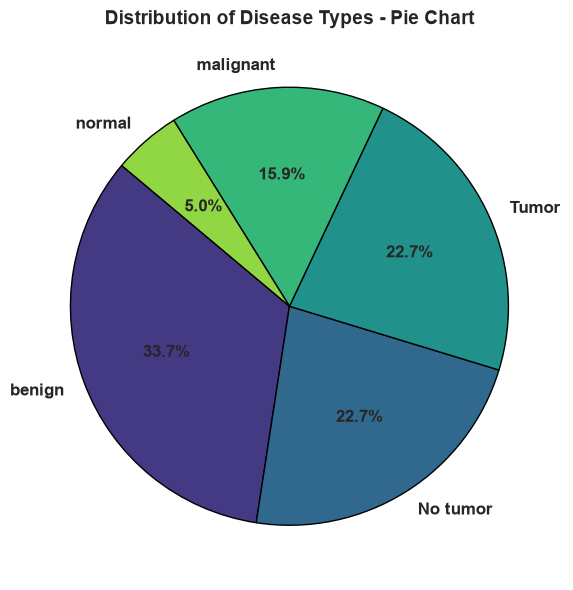

In [38]:
labels_counts=df['Label'].value_counts()
fig,ax=plt.subplots(figsize=(8,6))
colors=sns.color_palette('viridis',len(labels_counts))
ax.pie(labels_counts,labels=labels_counts.index,autopct='%1.1f%%',
       startangle=140,colors=colors,textprops={'fontsize':12,'weight':'bold'},
       wedgeprops={'edgecolor':'black','linewidth':1})
ax.set_title('Distribution of Disease Types - Pie Chart',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()


VISUALIZE THE IMAGES